## Example 2.2 - Use the Experiment Class to Extract EXAFS and Perform a Fourier-Transform on the EXAFS 

    In this example the EXAFS will be extracted from the XAS data in the Experiment Class object. The EXAFS will be visualized in k- and R-space.

    This example assumes that you have previoudly run '2.0 Example - Experiment Class -  XAS Data Import and Calibration' and have a saved 'pickled' file.


### Additional XAS processing steps will: 
    1. Extract EXAFS Spectra
    2. Fourier Transform the EXAFS Spectra  
    
### Steps:
    
    1. Import Modules
    2. Define Paths
    3. Open Saved Experiment using 'pickle'
    4. Extract EXAFS
    5. Perform Fourier-transform on EXAFS
    6. Save Experiment with 'pickle' 

### Things to have ready when attemtping this example:

    1. Directory and filename for the 'pickled' experiment 
    2. Scan name of one spectra in the experiment object
    
    
## Step 1. Import Modules

In [1]:
# File Handling:
import os
import pickle

# Plot Things:
import matplotlib.pyplot as plt

# Make things interactive:
import ipywidgets as widgets
from ipywidgets import interact, fixed, GridspecLayout
from IPython.display import display

# catXAS:
os.chdir('..')
pwd = os.getcwd()
os.chdir('./catxas')
import general as fcts
import xas as xfcts
import plot as pfcts
import process
import experiment as exp

# Plot Handling:
%matplotlib inline

In C:\Users\ashoff\.matplotlib\stylelib\mycustom.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In C:\Users\ashoff\.matplotlib\stylelib\mycustom.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In C:\Users\ashoff\.matplotlib\stylelib\scpy.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In C:\Users\ashoff\.matplotlib\stylelib\scpy.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


## Step 2. Define Paths

#### Modify:
    1. pickle_dir - directory containing the pickled experiment
    2. pickpe_name - filename of the pickled experiment (must include extension '.pickle')
    3. scan_name - a name of one fo the spectra in the experiment, used for interrogation throughout

In [2]:
# Directory Containing Experiment:
pickle_dir = os.path.join(pwd, 'sample results')

# Name of Experiment (must include extension '.pickle')
pickle_name = 'SnO2_TPR.pickle'

# Scan Naame for looking at parts of the Experiment Object
scan_name = '20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0001'

## Step 3. Open Saved Experiment using 'pickle'

    Pickle - A method to save the experimental class and reopen it elsewhere.

In [3]:
pickle_path = os.path.join(pickle_dir,pickle_name)
pickle_in = open(pickle_path,"rb")
my_exp = pickle.load(pickle_in)
pickle_in.close()

## Step 4. Extract EXAFS

    EXAFS extraction follows the same steps as Athena.

### Major Steps for EXAFS extraction:

    a. Define background subtraction parameters
    b. Import parameters into each spectrum's larch group
    c. Extract EXAFS

### 4a. Reference EXAFS Extraction 
#### 4a-1. Define background subtraction parameters
##### Modify:
    Paramters below. each paramters is annotated if there are preferred/required values

In [4]:
# Refernece background subtraction paramters

Ref_bkg_params = {'rbkg': 1,
                  'nknots': None, 
                  'kmin': 0, # Default value = 0, lower spline range
                  'kmax': 13, # Default value = None, upper spline range
                  'kweight': 1, # Default value = 1, Rarely Change
                  'dk': 0.1,
                  'win': 'hanning', 
                  'nfft': 2048, # Never Change 
                  'kstep': 0.05, # Never Change
                  'k_std': None, # Never Change
                  'chi_std': None, # Never Change
                  'nclamp': 2,
                  'clamp_lo': 1, 
                  'clamp_hi': 50, 
                  'err_sigma': 1
                   }

#### 4a-2. Import parameters into each reference spectrum's larch group

In [5]:
# Load background subtraction parameters into larch groups

# Reference
my_exp.load_params('mu Reference', Ref_bkg_params)

#### 5a-3. Extract EXAFS from the Reference Spectra

In [6]:
# Extract EXAFS for each spectum

# Reference
my_exp.extract_EXAFS_spectra('mu Reference')

#### 5a-4. Inspection tools to show results of the EXAFS Extraction
    1. Updated larch groups - experiment.spectra[scan_name]['Absorption Spectra']['mu Sample']
    2. Visualization of the extracted EXAFS

In [7]:
# 1. Inpsect updated 'mu Reference' group 

my_exp.spectra[scan_name]['Absorption Spectra']['mu Reference']

Attribute,Type,Value
energy,ndarray,"shape=(4839,), type=float64 range=[ 29004.2353: 30174.9982]"
mu,ndarray,"shape=(4839,), type=float64 range=[-0.14039600: 1.66162565]"
delE,float,1.0999999999985448
e0,float,29200.1048728863
pre1,int,-175
pre2,int,-100
norm1,int,120
norm2,int,950
nnorm,int,2
make_flat,bool,True


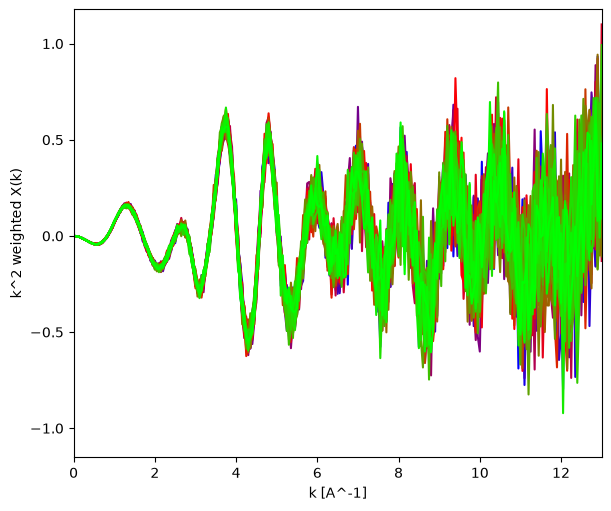

In [10]:
# 2. Visualization of the Extracted EXAFS

# MODIFY: k_weight, kmin, kmax for Sample and Reference

Ref_k_wt = 2
Ref_kmin = 0
Ref_kmax = 13

# DO NOT MODIFY BELOW

# Reference
    
R_groups = []

for key in my_exp.spectra.keys():
    R_groups.append(my_exp.spectra[key]['Absorption Spectra']['mu Reference'])

pfcts.plot_chi(R_groups, kweight = Ref_k_wt, kmin = Ref_kmin, kmax = Ref_kmax, 
               overlay = True, use_legend = False)

### 4b. Sample EXAFS Extraction 
#### 4b-1. Define background subtraction parameters
##### Modify:
    Paramters below. each paramters is annotated if there are preferred/required values

In [11]:
# Sample background subtraction paramters

Samp_bkg_params = {'rbkg': 1,
                  'nknots': None, 
                  'kmin': 0, # Default value = 0, lower spline range
                  'kmax': 13, # Default value = None, upper spline range
                  'kweight': 1, # Default value = 1, Rarely Change
                  'dk': 0.1,
                  'win': 'hanning', 
                  'nfft': 2048, # Never Change 
                  'kstep': 0.05, # Never Change
                  'k_std': None, # Never Change
                  'chi_std': None, # Never Change
                  'nclamp': 2,
                  'clamp_lo': 1, 
                  'clamp_hi': 100, 
                  'err_sigma': 1
                   }

#### 4b-2. Import parameters into each spectrum's larch group

In [17]:
# Load background subtraction parameters into larch groups

# Sample
my_exp.load_params('mu Sample', Samp_bkg_params)

#### 4b-3. Extract EXAFS from the Sample Spectra

In [13]:
# Extract EXAFS for each spectum

# Sample
my_exp.extract_EXAFS_spectra('mu Sample')

#### 4b-4. Inspection tools to show results of the EXAFS Extraction
    1. Updated larch groups - experiment.spectra[scan_name]['Absorption Spectra']['mu Sample']
    2. Visualization of the extracted EXAFS

In [14]:
# 1. Inpsect updated 'mu Sample' group 

my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample']

Attribute,Type,Value
energy,ndarray,"shape=(4839,), type=float64 range=[ 29004.2353: 30174.9982]"
mu,ndarray,"shape=(4839,), type=float64 range=[-0.94510060: 0.82209348]"
delE,float,1.0999999999985448
e0,float,29201.7285365002
pre1,int,-175
pre2,int,-100
norm1,int,120
norm2,int,950
nnorm,int,2
make_flat,bool,True


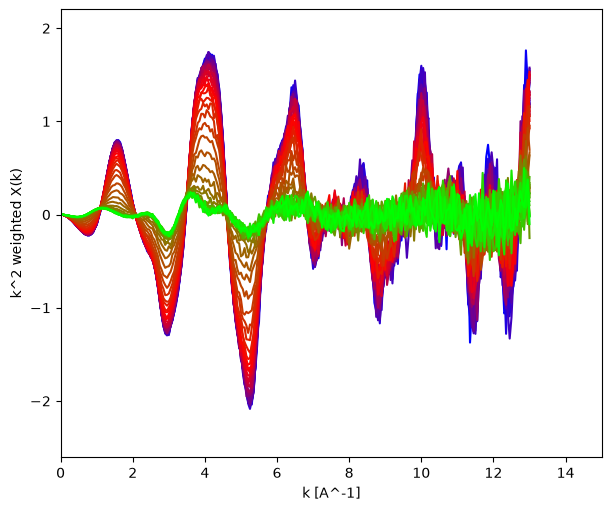

In [15]:
# 2. Visualization of the Extracted EXAFS

# MODIFY: k_weight, kmin, kmax for Sample and Reference

Samp_k_wt = 2
Samp_kmin = 0
Samp_kmax = 15

# DO NOT MODIFY BELOW

# Sample

S_groups = []

for key in my_exp.spectra.keys():
    S_groups.append(my_exp.spectra[key]['Absorption Spectra']['mu Sample'])
    
pfcts.plot_chi(S_groups, kweight = Samp_k_wt, kmin = Samp_kmin, kmax = Samp_kmax,
               overlay = True, use_legend = False)

## Step 5. Perform Fourier-transform on EXAFS

    Fourier-transform of the extracted EXAFS follows the same steps as Athena.

### Major Steps for Fourier-transform:

    a. Define Fourier-transform parameters
    b. Import parameters into each spectrum's larch group
    c. perform Fourier-transform

### 5a. Reference EXAFS Fourier-Transform 
#### 5a-1. Define background subtraction parameters
##### Modify:
    Paramters below. each paramters is annotated if there are preferred/required values

In [16]:
# Refernece FT paramters
Ref_FT_params = {'rmax_out': 10,
                  'kmin': 3,
                  'kmax': 11,
                  'kweight': 2,
                  'dk': 5,
                  'dk2': 5,
                  'window': 'haning',
                  'nfft': 2048, # Never Change
                  'kstep': 0.05 # Never Change
                 }

#### 5a-2. Import parameters into each spectrum's larch group

In [18]:
# Load FT parameters into larch groups

# Reference
my_exp.load_params('mu Reference', Ref_FT_params)

#### 5a-3. Peform Fourier-Transform on the EXAFS from the Sample Spectra

In [19]:
# Perform FT of EXAFS for each spectum

# Reference
my_exp.FT_EXAFS_spectra('mu Reference')

#### 5a-4. Inspection tools to show results of the Fourier-tranform
    1. Updated larch groups - experiment.spectra[scan_name]['Absorption Spectra']['mu Sample']
    2. Visualization of the FT EXAFS

In [20]:
# 1. Inpsect updated 'mu Reference' group 

my_exp.spectra[scan_name]['Absorption Spectra']['mu Reference']

Attribute,Type,Value
energy,ndarray,"shape=(4839,), type=float64 range=[ 29004.2353: 30174.9982]"
mu,ndarray,"shape=(4839,), type=float64 range=[-0.14039600: 1.66162565]"
delE,float,1.0999999999985448
e0,float,29200.1048728863
pre1,int,-175
pre2,int,-100
norm1,int,120
norm2,int,950
nnorm,int,2
make_flat,bool,True


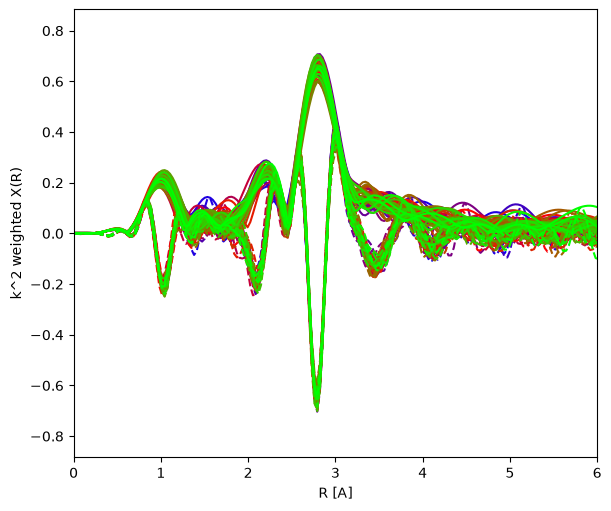

In [21]:
# 2. Visualization of the Fourier-Transformed EXAFS

# MODIFY: Rmin, Rmax, magnitide, imaginary, real for Sample and Reference

Ref_Rmin = 0
Ref_Rmax = 6
Ref_magnitude = True # Show Magnutide of FT
Ref_imaginary = True # Show Imaginary Component of FT
Ref_real = False # Show Real Component of FT

# DO NOT MODIFY BELOW

# Reference
    
R_groups = []

for key in my_exp.spectra.keys():
    R_groups.append(my_exp.spectra[key]['Absorption Spectra']['mu Reference'])

pfcts.plot_FT(R_groups, Rmin = Ref_Rmin, Rmax = Ref_Rmax, 
              magnitude = Ref_magnitude, imaginary = Ref_imaginary, real = Ref_real, 
              overlay = True, use_legend = False)

### 5b. Sample EXAFS Fourier-Transform 
#### 5b-1. Define background subtraction parameters
##### Modify:
    Paramters below. each paramters is annotated if there are preferred/required values

In [22]:
# Sample FT paramters
Samp_FT_params = {'rmax_out': 10,
                  'kmin': 3,
                  'kmax': 11,
                  'kweight': 2,
                  'dk': 5,
                  'dk2': 5,
                  'window': 'haning',
                  'nfft': 2048, # Never Change
                  'kstep': 0.05 # Never Change
                 }

#### 5b-2. Import parameters into each spectrum's larch group

In [23]:
# Load FT parameters into larch groups

# Sample
my_exp.load_params('mu Sample', Samp_FT_params)

#### 5b-3. Peform Fourier-Transform on the EXAFS from the Sample Spectra

In [24]:
# Perform FT of EXAFS for each spectum

# Sample
my_exp.FT_EXAFS_spectra('mu Sample')

#### 5b-4. Inspection tools to show results of the Fourier-tranform
    1. Updated larch groups - experiment.spectra[scan_name]['Absorption Spectra']['mu Sample']
    2. Visualization of the FT EXAFS

In [25]:
# 1. Inpsect updated 'mu Sample' group 

my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample']

Attribute,Type,Value
energy,ndarray,"shape=(4839,), type=float64 range=[ 29004.2353: 30174.9982]"
mu,ndarray,"shape=(4839,), type=float64 range=[-0.94510060: 0.82209348]"
delE,float,1.0999999999985448
e0,float,29201.7285365002
pre1,int,-175
pre2,int,-100
norm1,int,120
norm2,int,950
nnorm,int,2
make_flat,bool,True


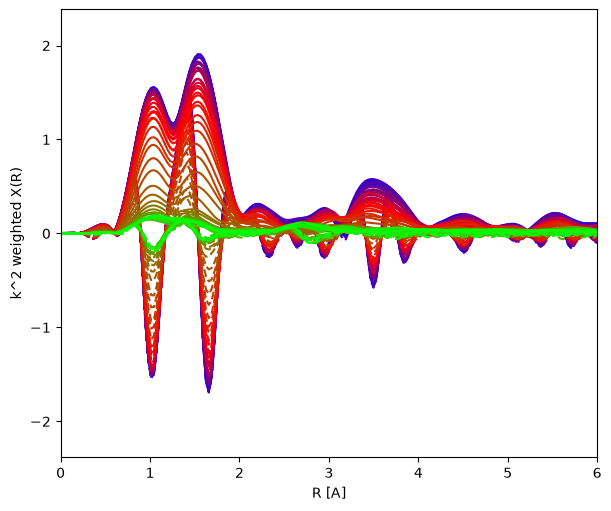

In [26]:
# 2. Visualization of the Fourier-Transformed EXAFS

# MODIFY: Rmin, Rmax, magnitide, imaginary, real for Sample and Reference

Samp_Rmin = 0
Samp_Rmax = 6
Samp_magnitude = True # Show Magnutide of FT
Samp_imaginary = True # Show Imaginary Component of FT
Samp_real = False # Show Real Component of FT

# DO NOT MODIFY BELOW

# Sample

S_groups = []

for key in my_exp.spectra.keys():
    S_groups.append(my_exp.spectra[key]['Absorption Spectra']['mu Sample'])
    
pfcts.plot_FT(S_groups, Rmin = Samp_Rmin, Rmax = Samp_Rmax, 
              magnitude = Samp_magnitude, imaginary = Samp_imaginary, real = Samp_real, 
              overlay = True, use_legend = False)

## Step 6. Save Experiment with 'pickle' 
    Pickle - A method to save the experimental class and reopen it elsewhere.

In [27]:
pickle_out = open(pickle_path,"wb")
pickle.dump(my_exp, pickle_out)
pickle_out.close()